Contexto:

Una cadena de heladerías busca expandirse en la CDMX. El gerente solicitó un análisis que permita conocer la situación actual del mercado y proponer 2 ubicaciones con mayor potencial de éxito.
Realiza una presentación ejecutiva de máximo 5 láminas en donde expliques:

1.     Fuentes usadas y su procesamiento (INEGI, DENUE, OpenStreetMap, etc…)

2.     Definición y distribución de la población objetivo (demanda) así como su relación con la competencia actual (oferta)

3.     Mapa de propuesta de ubicación y su área de influencia

4.     Justificación de la elección

5.     Conclusiones y siguientes pasos: ¿Qué otros datos usarías si tuvieras más tiempo, información y/o presupuesto?

 

Deberás de enviar nombrados con tu nombre y “_Ejercicio1”

 

·      Código (jupyter notebook o script) con el procesamiento de los datos

·      Si decides realizar el análisis directamente en un SIG, envía un reporte de procesamiento geográfico con una bitácora de procesos y sus parámetros técnicos, debes incluir capturas

·      Archivo PPT o PDF de máximo cinco diapositivas.

In [1]:
import numpy as np
from sklearn import cluster
import geopandas as gpd
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import os


# Ruta de trabajo
Especifica tu lugar de trabajo para cargar la ruta correspondiente


In [2]:
# Desktop
carpeta = ('G:/Mi drive/Trabajo/pruebaDataLab/datos')

In [3]:
# Laptop
carpeta = ('G:/Mi unidad/Trabajo/pruebaDataLab/datos')

# Indetificación del codigo de clase SCIAN para heladerías
A partir de la obtención de este código la tarea de descarga de la información del DENUE, será más sencilla, permitiendonos identificar y descargar las unidades económicas de nuestro ínteres.
https://www.inegi.org.mx/app/mapa/denue/default.aspx

In [4]:
scian = pd.read_excel(os.path.join(carpeta, 'clasificacion_scian_2023.xlsx'), sheet_name='UNION')
scian[scian['clase'].str.contains('hela', case=False, na=False)]

,cod_sector,sector,cod_subsector,subsector,cod_rama,rama,cod_subrama,subrama,cod_clase,clase
208,31,Industrias manufactureras,311,Industria alimentaria,3115,Elaboración de productos lácteos,31152,Elaboración de helados y paletas,311520,Elaboración de helados y paletas
558,46,Comercio al por menor,461,"Comercio al por menor de abarrotes, alimentos,...",4611,Comercio al por menor de abarrotes y alimentos,46117,Comercio al por menor de paletas de hielo y he...,461170,Comercio al por menor de paletas de hielo y he...


Con esta información descargamos la información del DENUE, acotando la busqueda de las unidades económicas de ínteres. <br>
https://www.inegi.org.mx/app/mapa/denue/default.aspx

# Carga de datos

In [5]:
# Carga datos denue
heladerias_00 =gpd.read_file(os.path.join(carpeta, 'INEGI_DENUE_09032026.gpkg'))
print(heladerias_00.shape)
heladerias_00.head(1) 

(1866, 43)


,id,clee,nom_estab,raz_social,codigo_act,nombre_act,per_ocu,tipo_vial,nom_vial,tipo_v_e_1,nom_v_e_1,tipo_v_e_2,nom_v_e_2,tipo_v_e_3,nom_v_e_3,numero_ext,letra_ext,edificio,edificio_e,numero_int,letra_int,tipo_asent,nomb_asent,tipoCenCom,nom_CenCom,num_local,cod_postal,cve_ent,entidad,cve_mun,municipio,cve_loc,localidad,ageb,manzana,telefono,correoelec,www,tipoUniEco,latitud,longitud,fecha_alta,geometry
0,10051076,09003461170002431000000000U3,PALETAS DE HIELO SIN NOMBRE,NaN,461170,Comercio al por menor de paletas de hielo y he...,0 a 5 personas,CALLE,SAN FAUSTINO,CALLE,SAN JORGE,AVENIDA,SANTA URSULA,CALLE,SAN VALENTIN,842,MZ 842 LT 16,NaN,NaN,NaN,NaN,COLONIA,PEDREGAL DE SANTA URSULA,NaN,NaN,NaN,04600,09,CIUDAD DE M�XICO,003,Coyoac�n,0001,Coyoac�n,0978,015,NaN,NaN,NaN,Fijo,19.309974,-99.161788,2024-11,POINT (-99.16179 19.30997)


In [6]:
# Carga de datos datos de colonias
colonias_00 = gpd.read_file(os.path.join(carpeta, 'colonias_cdmx_2023.json'))
print(colonias_00.shape)
colonias_00.head(1)

(1543, 8)


,cve_ent,entidad,cve_alc,alc,cve_col,colonia,clasif,geometry
0,09,Ciudad de México,002,Azcapotzalco,002-001,Aguilera,Colonia,"POLYGON ((-99.15913 19.47261, -99.15906 19.473..."


In [7]:
# Carga de datos poblacionales
manzanas_00 = gpd.read_file(os.path.join(carpeta, 'manzanas_cdmx_pobtot_2020.geojson'))
print(manzanas_00.shape)
manzanas_00.head(1)

(66386, 260)


,CVEGEO,POB1,POB2,POB2_R,POB4,POB4_R,POB5,POB5_R,POB6,POB6_R,POB7,POB7_R,POB8,POB8_R,POB9,POB9_R,POB10,POB10_R,POB11,POB11_R,POB12,POB12_R,POB13,POB13_R,POB14,POB14_R,POB15,POB15_R,POB17,POB17_R,POB18,POB18_R,POB19,POB19_R,POB20,POB20_R,POB21,POB21_R,POB22,POB22_R,POB23,POB23_R,POB24,POB24_R,POB25,POB25_R,POB42,POB42_R,POB43,POB43_R,POB45,POB45_R,POB46,POB46_R,POB47,POB47_R,POB48,POB48_R,POB49,POB49_R,POB50,POB50_R,POB51,POB51_R,POB52,POB52_R,POB53,POB53_R,POB54,POB54_R,POB55,POB55_R,POB56,POB56_R,POB57,POB57_R,POB59,POB59_R,POB60,POB60_R,POB61,POB61_R,POB62,POB62_R,POB63,POB63_R,POB64,POB64_R,POB65,POB65_R,POB66,POB66_R,POB67,POB67_R,POB84,POB84_R,POB85,POB85_R,POB87,POB87_R,POB88,POB88_R,POB89,POB89_R,POB90,POB90_R,POB91,POB91_R,POB92,POB92_R,POB93,POB93_R,POB94,POB94_R,POB95,POB95_R,POB96,POB96_R,POB97,POB97_R,POB98,POB98_R,POB100,POB100_R,POB101,POB101_R,POB102,POB102_R,POB103,POB103_R,POB104,POB104_R,POB105,POB105_R,POB106,POB106_R,POB107,POB107_R,POB108,POB108_R,POB125_R,POB126_R,POB127_R,POB128_R,POB129_R,POB130_R,POB131_R,POB132_R,POB133_R,POB134_R,POB3,POB3_R,POB16,POB16_R,POB26,POB26_R,POB27,POB27_R,POB28,POB28_R,POB29,POB29_R,POB30,POB30_R,POB31,POB31_R,POB32,POB32_R,POB33,POB33_R,POB34,POB34_R,POB35,POB35_R,POB36,POB36_R,POB37,POB37_R,POB38,POB38_R,POB39,POB39_R,POB40,POB40_R,POB41,POB41_R,POB44,POB44_R,POB58,POB58_R,POB68,POB68_R,POB69,POB69_R,POB70,POB70_R,POB71,POB71_R,POB72,POB72_R,POB73,POB73_R,POB74,POB74_R,POB75,POB75_R,POB76,POB76_R,POB77,POB77_R,POB78,POB78_R,POB79,POB79_R,POB80,POB80_R,POB81,POB81_R,POB82,POB82_R,POB83,POB83_R,POB86,POB86_R,POB99,POB99_R,POB109,POB109_R,POB110,POB110_R,POB111,POB111_R,POB112,POB112_R,POB113,POB113_R,POB114,POB114_R,POB115,POB115_R,POB116,POB116_R,POB117,POB117_R,POB118,POB118_R,POB119,POB119_R,POB120,POB120_R,POB121,POB121_R,POB122,POB122_R,POB123,POB123_R,POB124,POB124_R,OID,geometry
0,0901000010898031,93.0,4.0,4.3,-6.0,-6.0,5.0,5.4,9.0,9.7,5.0,5.4,16.0,17.2,3.0,3.2,11.0,11.8,17.0,18.3,58.0,62.4,8.0,8.6,27.0,29.0,9.0,9.7,89.0,95.7,87.0,93.5,82.0,88.2,77.0,82.8,74.0,79.6,66.0,71.0,24.0,25.8,19.0,20.4,17.0,18.3,56.0,60.2,-6.0,-6.0,-6.0,-6.0,3.0,3.2,7.0,7.5,5.0,5.4,10.0,10.8,0.0,0.0,7.0,7.5,10.0,10.8,27.0,29.0,36.0,38.7,7.0,7.5,17.0,18.3,4.0,4.3,55.0,59.1,54.0,58.1,51.0,54.8,46.0,49.5,46.0,49.5,39.0,41.9,15.0,16.1,10.0,10.8,8.0,8.6,37.0,39.8,3.0,3.2,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,0.0,0.0,6.0,6.5,3.0,3.2,4.0,4.3,7.0,7.5,22.0,23.7,-6.0,-6.0,10.0,10.8,5.0,5.4,34.0,36.6,33.0,35.5,31.0,33.3,31.0,33.3,28.0,30.1,27.0,29.0,9.0,9.7,9.0,9.7,9.0,9.7,66.1,60.3,27.6,32.8,39.0,39.0,40.0,150.0,150.0,150.0,6.0,6.5,5.0,5.4,5.0,5.4,5.0,5.4,5.0,5.4,6.0,6.5,6.0,6.5,7.0,7.5,7.0,7.5,8.0,8.6,5.0,5.4,7.0,7.5,-6.0,-6.0,-6.0,-6.0,10.0,10.8,-6.0,-6.0,-6.0,-6.0,3.0,3.2,-6.0,-6.0,5.0,5.4,3.0,3.2,5.0,5.4,-6.0,-6.0,5.0,5.4,3.0,3.2,4.0,4.3,5.0,5.4,5.0,5.4,3.0,3.2,3.0,3.2,-6.0,-6.0,-6.0,-6.0,4.0,4.3,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,4.0,4.3,0.0,0.0,-6.0,-6.0,0.0,0.0,3.0,3.2,-6.0,-6.0,3.0,3.2,3.0,3.2,-6.0,-6.0,3.0,3.2,-6.0,-6.0,4.0,4.3,-6.0,-6.0,0.0,0.0,6.0,6.5,-6.0,-6.0,0.0,0.0,-6.0,-6.0,1,"MULTIPOLYGON (((-99.22982 19.35939, -99.23058 ..."


# Procesamiento de datos

In [8]:
# Identificación y extracción de columnas de interés (grupos por edad)
# Lista de variables absolutas (valores brutos) para filtrar
variables = [
    'POB1',      # Población total
    'POB3',      # 0 - 4
    'POB26',     # 5 - 9
    'POB27',     # 10 - 14 
    'POB28',     # 15 - 19 
    'POB29',     # 20 - 24 
    'POB30',     # 25 - 29 
    'POB31',     # 30 - 34 
    'POB32',     # 35 - 39 
    'POB33',     # 40 - 44 
    'POB34',     # 45 - 49 
    'POB35',     # 50 - 54 
    'POB36',     # 55 - 59 
    'POB37',     # 65 - 69 
    'POB38',     # 70 - 74 
    'POB39',     # 75 - 79 
    'POB40',     # 80 - 84 
    'POB41',     # 85  y más
]

In [9]:
manzanas_01 = manzanas_00[['CVEGEO', 'geometry'] + variables ].copy()
manzanas_01.head(1)

,CVEGEO,geometry,POB1,POB3,POB26,POB27,POB28,POB29,POB30,POB31,POB32,POB33,POB34,POB35,POB36,POB37,POB38,POB39,POB40,POB41
0,0901000010898031,"MULTIPOLYGON (((-99.22982 19.35939, -99.23058 ...",93.0,6.0,5.0,5.0,5.0,6.0,6.0,7.0,7.0,8.0,5.0,7.0,-6.0,-6.0,10.0,-6.0,-6.0,3.0


In [10]:
# Diccionario para renombrar columnas a nombres más descriptivos
renombrar = {
    'POB1':  'pob_total',
    'POB3':  'pob_0_4',
    'POB26': 'pob_5_9',
    'POB27': 'pob_10_14',
    'POB28': 'pob_15_19',
    'POB29': 'pob_20_24',
    'POB30': 'pob_25_29',
    'POB31': 'pob_30_34',
    'POB32': 'pob_35_39',
    'POB33': 'pob_40_44',
    'POB34': 'pob_45_49',
    'POB35': 'pob_50_54',
    'POB36': 'pob_55_59',
    'POB37': 'pob_65_69',
    'POB38': 'pob_70_74',
    'POB39': 'pob_75_79',
    'POB40': 'pob_80_84',
    'POB41': 'pob_85_mas',
}
# Renombramos
manzanas_01 = manzanas_01.rename(columns=renombrar)
# Remplazamos valores negativos por 0 (datos censurados, que no aplican, etc.)
manzanas_01 = manzanas_01.replace([-6,-7, -8], 0)
# Verificamos
manzanas_01.describe()


,pob_total,pob_0_4,pob_5_9,pob_10_14,pob_15_19,pob_20_24,pob_25_29,pob_30_34,pob_35_39,pob_40_44,pob_45_49,pob_50_54,pob_55_59,pob_65_69,pob_70_74,pob_75_79,pob_80_84,pob_85_mas
count,66386.000000,66386.000000,66386.000000,66386.000000,66386.000000,66386.000000,66386.000000,66386.000000,66386.000000,66386.000000,66386.000000,66386.000000,66386.000000,66386.000000,66386.000000,66386.000000,66386.000000,66386.000000
mean,137.656765,6.832194,8.115461,8.811014,9.458244,10.428569,11.026903,10.899738,10.328367,9.790091,9.780662,9.097280,7.623686,5.004368,3.622902,2.177688,1.288314,1.117555
std,189.013505,11.221773,12.686591,13.300437,13.828078,15.259681,17.860293,19.365466,18.465710,16.338122,15.162178,13.276068,10.947619,7.234572,5.565184,3.857217,2.778395,2.725184
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,43.000000,0.000000,0.000000,0.000000,0.000000,3.000000,3.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,92.000000,4.000000,5.000000,5.000000,6.000000,7.000000,7.000000,7.000000,6.000000,6.000000,6.000000,6.000000,5.000000,4.000000,3.000000,0.000000,0.000000,0.000000
75%,169.000000,9.000000,11.000000,11.000000,12.000000,13.000000,14.000000,13.000000,13.000000,12.000000,13.000000,12.000000,10.000000,7.000000,6.000000,4.000000,3.000000,0.000000
max,10484.000000,533.000000,613.000000,626.000000,738.000000,767.000000,1423.000000,1819.000000,1808.000000,1482.000000,1111.000000,788.000000,661.000000,388.000000,302.000000,202.000000,136.000000,128.000000


In [11]:
# Agregamos información de manzanas a colonias
manzanas_01['geometry'] = manzanas_01['geometry'].centroid
# Spatial join: cada centroide obtiene la cve_col de su colonia
manzanas_02 = gpd.sjoin(
    manzanas_01,
    colonias_00[["cve_col", "geometry"]],
    how="left",
    predicate="within"
)
manzanas_02['cve_col'].head()

C:\Users\COMIMSA\AppData\Local\Temp\ipykernel_13612\2157294847.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  manzanas_01['geometry'] = manzanas_01['geometry'].centroid


0    010-091
1    010-225
2    010-217
3    010-198
4    010-093
Name: cve_col, dtype: str

In [12]:
# Agrupar por cve_col y sumar datos
mzn_por_colonia = (
    manzanas_02
    .groupby("cve_col")
    .agg(
        n_manzanas=("pob_total", "count"),
        **{col: (col, "sum") for col in manzanas_02.select_dtypes("number").columns}
    )
    .reset_index()
)

# Unir a colonias
colonias_01 = colonias_00.merge(mzn_por_colonia, on="cve_col", how="left")
# Calcular campos de densidad y superficie
colonias_01['sup_m2']  = colonias_01['geometry'].to_crs(epsg=32614).area
colonias_01['sup_ha']  = colonias_01['geometry'].to_crs(epsg=32614).area / 10000
colonias_01['sup_km2'] = colonias_01['geometry'].to_crs(epsg=32614).area / 1000000
colonias_01['densidad_pob'] = colonias_01['pob_total'] / colonias_01['sup_ha']
colonias_01.head(1)

,cve_ent,entidad,cve_alc,alc,cve_col,colonia,clasif,geometry,n_manzanas,pob_total,pob_0_4,pob_5_9,pob_10_14,pob_15_19,pob_20_24,pob_25_29,pob_30_34,pob_35_39,pob_40_44,pob_45_49,pob_50_54,pob_55_59,pob_65_69,pob_70_74,pob_75_79,pob_80_84,pob_85_mas,index_right,sup_m2,sup_ha,sup_km2,densidad_pob
0,09,Ciudad de México,002,Azcapotzalco,002-001,Aguilera,Colonia,"POLYGON ((-99.15913 19.47261, -99.15906 19.473...",10.0,1957.0,83.0,114.0,108.0,128.0,136.0,137.0,137.0,147.0,133.0,128.0,144.0,130.0,102.0,72.0,42.0,47.0,29.0,0.0,99479.51884,9.947952,0.09948,196.723911


In [13]:
# join espacial, 
heladerias_01 = gpd.sjoin(
    heladerias_00.to_crs(4326),
    colonias_01[["cve_col", "geometry"]],
    how="left",
    predicate="within"
)
# Agrupar por cve_col y sumar datos
hld_por_colonia = (
    heladerias_01
    .groupby("cve_col")
    .agg(
        n_heladerias=("id", "count")
    )
    .reset_index()
)
# Unir información de heladerías a colonias
colonias_02 = colonias_01.merge(hld_por_colonia, on="cve_col", how="left")
colonias_02['den_helado_ha'] = colonias_02['n_heladerias'] / colonias_02['sup_ha']

colonias_02.head(1)

,cve_ent,entidad,cve_alc,alc,cve_col,colonia,clasif,geometry,n_manzanas,pob_total,pob_0_4,pob_5_9,pob_10_14,pob_15_19,pob_20_24,pob_25_29,pob_30_34,pob_35_39,pob_40_44,pob_45_49,pob_50_54,pob_55_59,pob_65_69,pob_70_74,pob_75_79,pob_80_84,pob_85_mas,index_right,sup_m2,sup_ha,sup_km2,densidad_pob,n_heladerias,den_helado_ha
0,09,Ciudad de México,002,Azcapotzalco,002-001,Aguilera,Colonia,"POLYGON ((-99.15913 19.47261, -99.15906 19.473...",10.0,1957.0,83.0,114.0,108.0,128.0,136.0,137.0,137.0,147.0,133.0,128.0,144.0,130.0,102.0,72.0,42.0,47.0,29.0,0.0,99479.51884,9.947952,0.09948,196.723911,NaN,NaN


## Perfiles poblacionales por estructura de edad

In [14]:
# Agrupar en macrogrupos etarios (útil para interpretar clusters)
colonias_02['grupo_ninos']        = colonias_02[['pob_0_4', 'pob_5_9', 'pob_10_14', 'pob_15_19']].sum(axis=1) 
colonias_02['grupo_jovenes']      = colonias_02[['pob_20_24', 'pob_25_29']].sum(axis=1) 
colonias_02['grupo_adulto_joven'] = colonias_02[['pob_30_34', 'pob_35_39', 'pob_40_44']].sum(axis=1) 
colonias_02['grupo_adulto']       = colonias_02[['pob_45_49', 'pob_50_54', 'pob_55_59']].sum(axis=1) 
colonias_02['grupo_mayor']        = colonias_02[['pob_65_69', 'pob_70_74', 'pob_75_79','pob_80_84', 'pob_85_mas']].sum(axis=1)

grupos = ['grupo_ninos', 'grupo_jovenes', 'grupo_adulto_joven',
                'grupo_adulto', 'grupo_mayor']

colonias_02[['pob_total'] + grupos].head()

,pob_total,grupo_ninos,grupo_jovenes,grupo_adulto_joven,grupo_adulto,grupo_mayor
0,1957.0,433.0,273.0,417.0,402.0,292.0
1,3371.0,792.0,511.0,745.0,694.0,372.0
2,1006.0,188.0,129.0,205.0,171.0,144.0
3,6325.0,1538.0,942.0,2273.0,1063.0,263.0
4,1830.0,358.0,299.0,443.0,408.0,217.0


In [15]:
colonias_03 = colonias_02.copy()
# Calcular porcentajes
for col in grupos:
    colonias_03[f'pct_{col}'] = colonias_02[col] / colonias_02['pob_total'].replace(0, np.nan)

col_pct = [f'pct_{c}' for c in grupos]

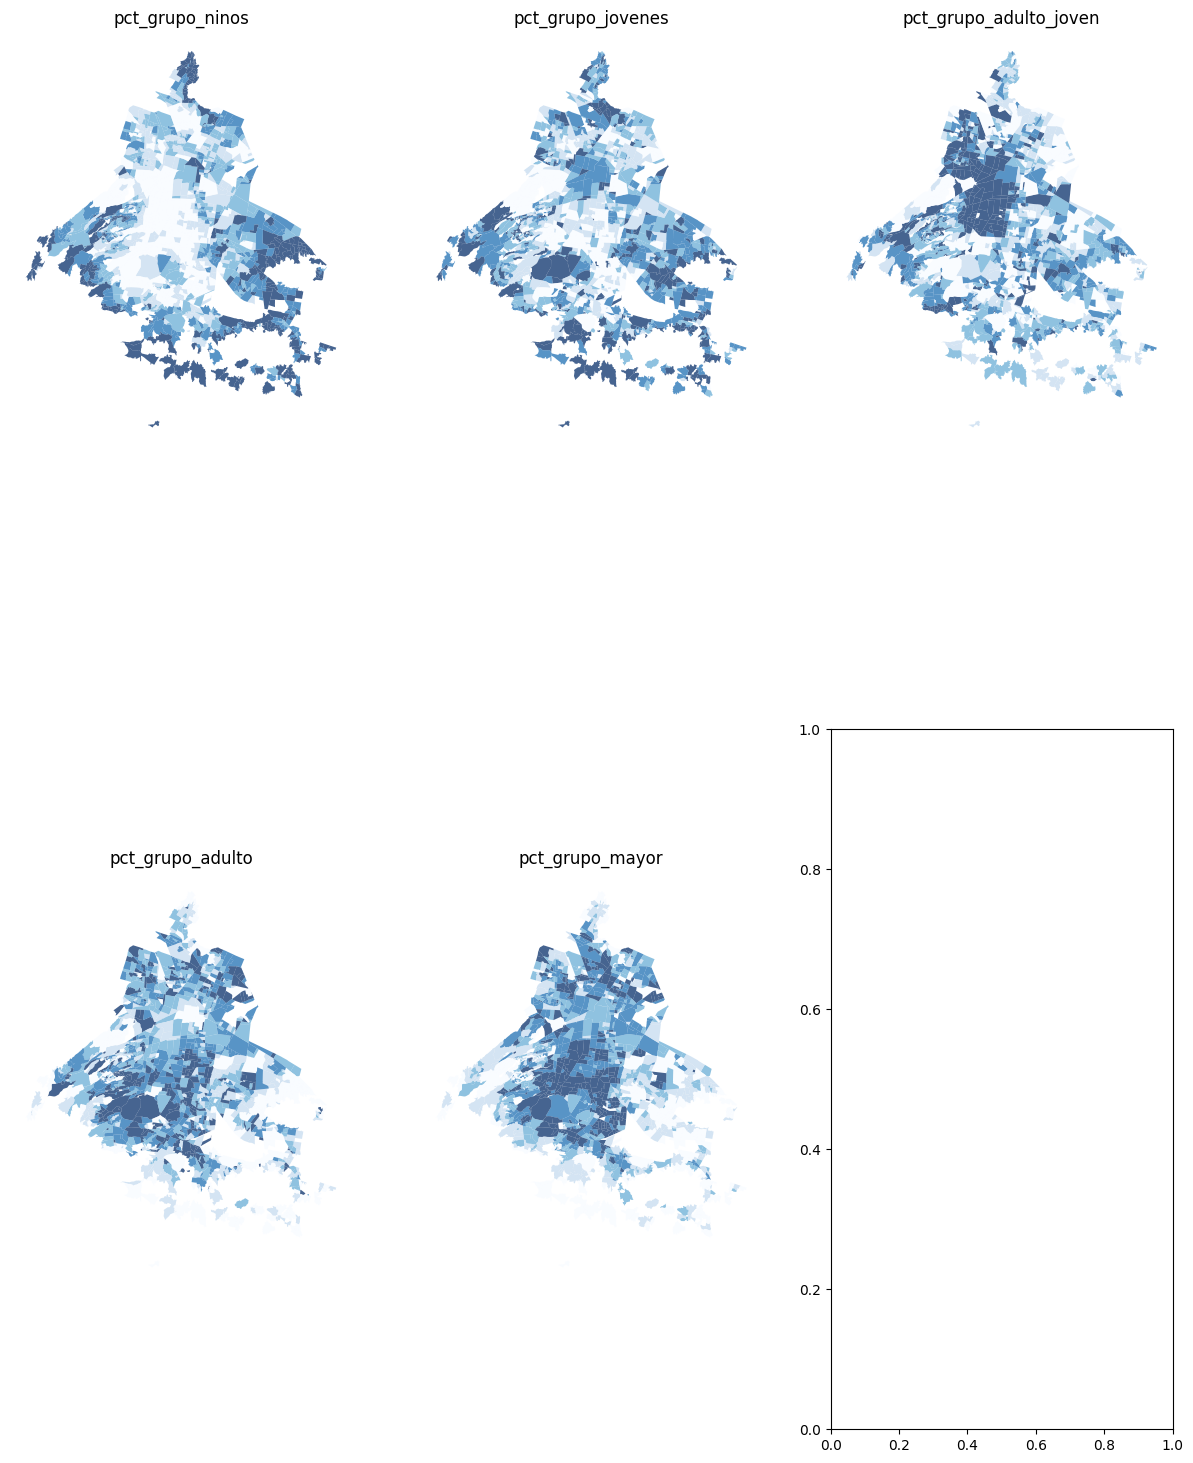

In [16]:
# Graficamos
f, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 20))
axs = axs.flatten()

for i, col in enumerate(col_pct):
    ax = axs[i]
    colonias_03.plot(
        column=col, 
        ax=ax, 
        scheme='Quantiles',
        linewidth=0, 
        cmap='Blues', 
        alpha=0.75
    )
    ax.set_axis_off()
    ax.set_title(col)
plt.show()

In [17]:
# Filtramos colonias que no tienen población total (para evitar distorsiones al calcular porcentajes) y rellenamos NA con 0
colonias_04 = colonias_03[colonias_03['pob_total'] != 0].copy()
colonias_04[col_pct] = colonias_04[col_pct].fillna(0)

## Agrupamiento por similitud

In [26]:
# aplicamos el algoritmo de clustering K-means definiendo 5 clusters 
kmeans4 = cluster.KMeans(n_clusters=4, random_state=12345)
k4cls = kmeans4.fit(colonias_04[col_pct])
# Obtener etiquetas de cluster y asignar a colonias
colonias_04['k4cls'] = k4cls.labels_

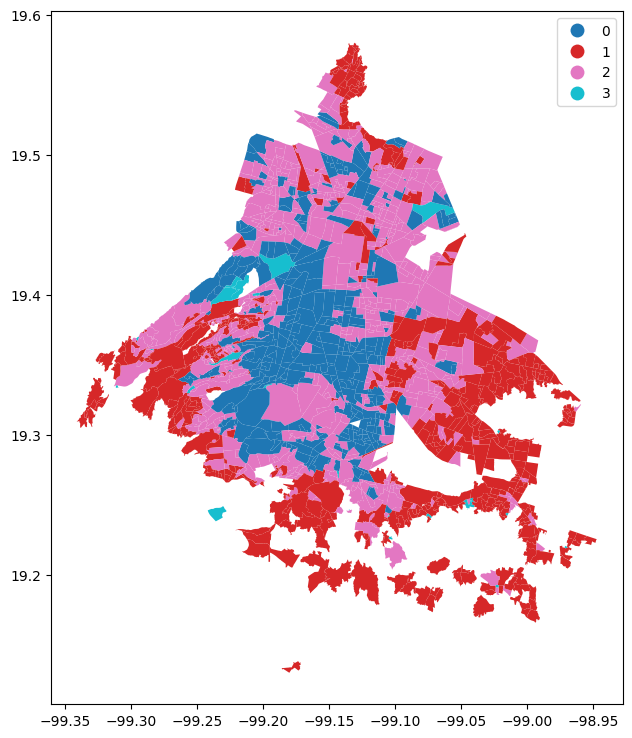

In [27]:
# Mapeamos clusters
f, ax = plt.subplots(1, figsize=(9, 9))
colonias_04.plot(column='k4cls', categorical=True, legend=True, linewidth=0, ax=ax)
plt.show()

In [29]:
# Calculamos valores promedio por grupo
k4cls = colonias_04.groupby('k4cls')[col_pct].mean()
# Transponemos la tabla
k4cls.T.round(2)

k4cls,0,1,2,3
pct_grupo_ninos,0.15,0.30,0.23,0.01
pct_grupo_jovenes,0.13,0.17,0.15,0.01
pct_grupo_adulto_joven,0.21,0.22,0.22,0.01
pct_grupo_adulto,0.21,0.18,0.20,0.02
pct_grupo_mayor,0.16,0.06,0.10,0.02


## Definición de grupos
Analizamos la distribución de los valores por grupo y los caracterizamos
- Grupo 0: Equilibrado; sin grupo de edad predominante
- Grupo 1: Familiar con niños; Alta presencia de poblaciones jovenes 
- Grupo 2: Adultos activos; Alta presencia de adultos (30 a 44 años)  y pocos niños
- Grupo 3: Despoblado; colonias con poca población

In [ ]:
grupos_nombres = {
    0: 'Colonias Equilibradas',
    1: 'Colonias Familiares con niños',
    2: 'Colonias Adultos Activas',
    3: 'Colonias sin poblacion'
}
colonias_04['k4cls_nombre'] = colonias_04['k4cls'].map(grupos_nombres)

In [36]:
colonias_04.head(1)

,cve_ent,entidad,cve_alc,alc,cve_col,colonia,clasif,geometry,n_manzanas,pob_total,pob_0_4,pob_5_9,pob_10_14,pob_15_19,pob_20_24,pob_25_29,pob_30_34,pob_35_39,pob_40_44,pob_45_49,pob_50_54,pob_55_59,pob_65_69,pob_70_74,pob_75_79,pob_80_84,pob_85_mas,index_right,sup_m2,sup_ha,sup_km2,densidad_pob,n_heladerias,den_helado_ha,grupo_ninos,grupo_jovenes,grupo_adulto_joven,grupo_adulto,grupo_mayor,pct_grupo_ninos,pct_grupo_jovenes,pct_grupo_adulto_joven,pct_grupo_adulto,pct_grupo_mayor,k5cls,k4cls,k4cls_nombre
0,09,Ciudad de México,002,Azcapotzalco,002-001,Aguilera,Colonia,"POLYGON ((-99.15913 19.47261, -99.15906 19.473...",10.0,1957.0,83.0,114.0,108.0,128.0,136.0,137.0,137.0,147.0,133.0,128.0,144.0,130.0,102.0,72.0,42.0,47.0,29.0,0.0,99479.51884,9.947952,0.09948,196.723911,NaN,NaN,433.0,273.0,417.0,402.0,292.0,0.221257,0.139499,0.213081,0.205416,0.149208,2,2,Colonias Adultos Activas


In [66]:
col_interes = ['cve_col', 'colonia','pob_total', 'densidad_pob', 'den_helado_ha', 'k4cls_nombre', 'geometry']

In [67]:
# Clusters de interés (excluimos Marginales)
clusters_interes = ['Colonias Equilibradas', 'Colonias Familiares con niños', 'Colonias Adultos Activas']

colonias_interes = colonias_04[
    (colonias_04['k4cls_nombre'].isin(clusters_interes)) &  # Clusters relevantes
    (colonias_04['den_helado_ha'] < colonias_04['den_helado_ha'].median()) &  # Baja competencia
    (colonias_04['densidad_pob'] > colonias_04['densidad_pob'].median())  # Alta densidad poblacional
][col_interes].copy()

In [73]:
colonias_04.head(1)

,cve_ent,entidad,cve_alc,alc,cve_col,colonia,clasif,geometry,n_manzanas,pob_total,pob_0_4,pob_5_9,pob_10_14,pob_15_19,pob_20_24,pob_25_29,pob_30_34,pob_35_39,pob_40_44,pob_45_49,pob_50_54,pob_55_59,pob_65_69,pob_70_74,pob_75_79,pob_80_84,pob_85_mas,index_right,sup_m2,sup_ha,sup_km2,densidad_pob,n_heladerias,den_helado_ha,grupo_ninos,grupo_jovenes,grupo_adulto_joven,grupo_adulto,grupo_mayor,pct_grupo_ninos,pct_grupo_jovenes,pct_grupo_adulto_joven,pct_grupo_adulto,pct_grupo_mayor,k5cls,k4cls,k4cls_nombre
0,09,Ciudad de México,002,Azcapotzalco,002-001,Aguilera,Colonia,"POLYGON ((-99.15913 19.47261, -99.15906 19.473...",10.0,1957.0,83.0,114.0,108.0,128.0,136.0,137.0,137.0,147.0,133.0,128.0,144.0,130.0,102.0,72.0,42.0,47.0,29.0,0.0,99479.51884,9.947952,0.09948,196.723911,NaN,NaN,433.0,273.0,417.0,402.0,292.0,0.221257,0.139499,0.213081,0.205416,0.149208,2,2,Colonias Adultos Activas


# Top 2 de colonias para poner un establecimiento de helados

In [68]:
print(f"Colonias totales en CDMX: {len(colonias_04)}")
print(f"Colonias de interés: {len(colonias_interes)}")
colonias_interes.sort_values('den_helado_ha').head(2)

Colonias totales en CDMX: 1538
Colonias de interés: 142


,cve_col,colonia,pob_total,densidad_pob,den_helado_ha,k4cls_nombre,geometry
1317,014-014,Del Valle Norte,23375.0,166.204586,0.007110,Colonias Equilibradas,"POLYGON ((-99.17332 19.39118, -99.17318 19.391..."
491,007-044,Cerro De La Estrella,22070.0,169.411200,0.007676,Colonias Adultos Activas,"POLYGON ((-99.0841 19.32018, -99.08404 19.3203..."


## Unión de datos

In [69]:
colonias_interes['ranking'] = colonias_interes['den_helado_ha'].rank(ascending=True).astype(int)
colonias_interes.sort_values('den_helado_ha').head()

,cve_col,colonia,pob_total,densidad_pob,den_helado_ha,k4cls_nombre,geometry,ranking
1317,014-014,Del Valle Norte,23375.0,166.204586,0.007110,Colonias Equilibradas,"POLYGON ((-99.17332 19.39118, -99.17318 19.391...",1
491,007-044,Cerro De La Estrella,22070.0,169.411200,0.007676,Colonias Adultos Activas,"POLYGON ((-99.0841 19.32018, -99.08404 19.3203...",2
978,011-030,Barrio Santa Ana Poniente,20528.0,183.571505,0.008942,Colonias Familiares con niños,"POLYGON ((-99.05227 19.30157, -99.05173 19.302...",3
1121,012-092,Pedregal De San Nicolas 4a Seccion,15959.0,152.699276,0.009568,Colonias Adultos Activas,"POLYGON ((-99.24446 19.27905, -99.24446 19.279...",4
1400,016-011,Anahuac I Seccion,16917.0,179.939097,0.010637,Colonias Adultos Activas,"POLYGON ((-99.18542 19.45194, -99.1848 19.4518...",5


In [76]:
colonias_05 = colonias_04.merge(colonias_interes[['cve_col', 'ranking']],on='cve_col', how='left')
colonias_05.head(1)

,cve_ent,entidad,cve_alc,alc,cve_col,colonia,clasif,geometry,n_manzanas,pob_total,pob_0_4,pob_5_9,pob_10_14,pob_15_19,pob_20_24,pob_25_29,pob_30_34,pob_35_39,pob_40_44,pob_45_49,pob_50_54,pob_55_59,pob_65_69,pob_70_74,pob_75_79,pob_80_84,pob_85_mas,index_right,sup_m2,sup_ha,sup_km2,densidad_pob,n_heladerias,den_helado_ha,grupo_ninos,grupo_jovenes,grupo_adulto_joven,grupo_adulto,grupo_mayor,pct_grupo_ninos,pct_grupo_jovenes,pct_grupo_adulto_joven,pct_grupo_adulto,pct_grupo_mayor,k5cls,k4cls,k4cls_nombre,ranking
0,09,Ciudad de México,002,Azcapotzalco,002-001,Aguilera,Colonia,"POLYGON ((-99.15913 19.47261, -99.15906 19.473...",10.0,1957.0,83.0,114.0,108.0,128.0,136.0,137.0,137.0,147.0,133.0,128.0,144.0,130.0,102.0,72.0,42.0,47.0,29.0,0.0,99479.51884,9.947952,0.09948,196.723911,NaN,NaN,433.0,273.0,417.0,402.0,292.0,0.221257,0.139499,0.213081,0.205416,0.149208,2,2,Colonias Adultos Activas,NaN


In [84]:
colonias_05["geometry"] = colonias_05["geometry"].simplify(tolerance=0.01, preserve_topology=True)
colonias_05["geometry"]


0       POLYGON ((-99.15292 19.47168, -99.15901 19.473...
1       POLYGON ((-99.14799 19.46953, -99.15088 19.473...
2       POLYGON ((-99.15927 19.47137, -99.15943 19.473...
3       POLYGON ((-99.15861 19.46385, -99.15411 19.468...
4       POLYGON ((-99.19321 19.4814, -99.19649 19.4852...
                              ...                        
1533    POLYGON ((-99.10566 19.43991, -99.10651 19.441...
1534    POLYGON ((-99.09791 19.41693, -99.08918 19.415...
1535    POLYGON ((-99.11494 19.45374, -99.12228 19.459...
1536    POLYGON ((-99.11109 19.43792, -99.11365 19.440...
1537    POLYGON ((-99.12606 19.42288, -99.12337 19.439...
Name: geometry, Length: 1538, dtype: geometry

In [ ]:
# colonias_05.to_file(os.path.join('..', 'datos', 'colonias_interes_heladerias.geojson'))
colonias_05.to_file(os.path.join(carpeta, 'colonias_interes_heladerias.geojson'))